In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno
# pl.Config.set_tbl_rows(15)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# Configuration and paths
min_range = -0
max_range = +500

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)

anno_config_df = anno_config_df.filter(pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']))

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list() + ['loftee_hc', 'consequence_intron_variant']
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
"""conservation""","""gpn_score""","""#942c80""","""GPN-MSA""",-1
"""conservation""","""verphylop""","""#6a1c81""","""Vertebrate PhyloP""",1
"""conservation""","""mamphylop""","""#440154""","""Mammalian PhyloP""",1
"""splicing""","""pangolin_score""","""#20c997""","""Pangolin""",1
"""splicing""","""delta_score""","""#00A99D""","""SpliceAI""",1
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#1E8449""","""AbSplice2 (max)""",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
variant_class = "intronic"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

anno = (
    anno
    .filter(
        filter_expression &
        # & (pl.col('consequence_splice_acceptor_variant') == 0) & (pl.col('consequence_splice_donor_variant') == 0)
        # (pl.col('consequence_splice_acceptor_variant') == 1) | (pl.col('consequence_splice_donor_variant') == 1)
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range)
        
        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)


anno

gene_name,mamphylop,gpn_star_llr_calibrated_mean,gene_length,TSS,id,absplice_dna_max,Strand,consequence_intron_variant,gpn_score,dist_to_tss,absplice2_max,pangolin_score,cadd_raw,region,delta_score,verphylop,loftee_hc
str,f32,f64,i64,i64,str,f32,cat,i8,f32,i64,f32,f32,f32,str,f32,f32,i8
"""LRP2""",0.774,0.153293,235427,169362534,"""chr2:169197167:T:G""",0.001,"""-""",1,-1.5,165367,0.000033,0.0,0.466688,"""ENSG00000081479""",0.0,0.217,0
"""LRP2""",0.085,1.684965,235427,169362534,"""chr2:169204292:A:T""",0.003,"""-""",1,-0.63,158242,0.000116,0.0,0.104863,"""ENSG00000081479""",0.01,0.291,0
"""ABCB11""",0.015,-1.212965,115828,169031324,"""chr2:169030531:C:T""",0.001,"""-""",1,-1.64,793,0.000033,0.0,0.326902,"""ENSG00000073734""",0.0,0.023,0
"""ABCB11""",0.19,-0.238119,115828,169031324,"""chr2:169007174:C:T""",0.001,"""-""",1,0.08,24150,0.000033,0.0,-0.070862,"""ENSG00000073734""",0.0,0.193,0
"""LRP2""",0.117,-1.768037,235427,169362534,"""chr2:169175752:G:A""",0.001,"""-""",1,-0.98,186782,0.000033,0.0,0.211538,"""ENSG00000081479""",0.0,0.117,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CD200""",-1.553,0.631638,30467,112332346,"""chr3:112365432:T:C""",0.0,"""+""",1,1.12,33086,0.0,0.0,-0.577349,"""ENSG00000091972""",0.0,-1.497,0
"""CD200""",-0.073,0.406711,30467,112332346,"""chr3:112330089:T:G""",0.0,"""+""",1,-4.13,-2257,0.0,0.0,0.73253,"""ENSG00000091972""",0.0,-0.052,0
"""CD200""",0.392,-1.380881,30467,112332346,"""chr3:112329326:T:C""",0.0,"""+""",1,-1.89,-3020,0.0,0.0,0.636473,"""ENSG00000091972""",0.0,0.407,0


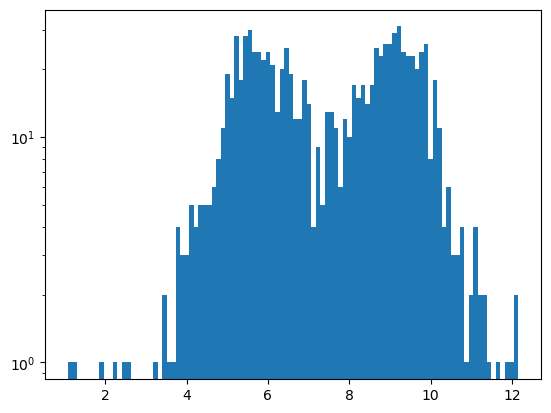

In [4]:

plt.hist(anno.filter(pl.col('loftee_hc')==1)['cadd_raw'], bins=100, log=True)
plt.show()

In [5]:
anno2use = 'cadd_raw'

lof_anno_min = anno.filter(pl.col('loftee_hc')==1)[anno2use].min()
lof_anno_med = anno.filter(pl.col('loftee_hc')==1)[anno2use].median()
lof_anno_q25 = anno.filter(pl.col('loftee_hc') == 1)[anno2use].quantile(0.25)

anno_hi = (
    anno
    .filter(
        # (pl.col(anno2use) >= lof_anno_min)
        (pl.col(anno2use) >= lof_anno_q25)
        # (pl.col(anno2use) >= lof_anno_med)
    )
)

anno_hi

gene_name,mamphylop,gpn_star_llr_calibrated_mean,gene_length,TSS,id,absplice_dna_max,Strand,consequence_intron_variant,gpn_score,dist_to_tss,absplice2_max,pangolin_score,cadd_raw,region,delta_score,verphylop,loftee_hc
str,f32,f64,i64,i64,str,f32,cat,i8,f32,i64,f32,f32,f32,str,f32,f32,i8
"""SCN2A""",0.112,-5.083347,197319,165194992,"""chr2:165388619:T:G""",0.284095,"""+""",1,-8.04,193627,0.422038,0.57,7.015543,"""ENSG00000136531""",0.9,2.217,0
"""LRP2""",0.041,0.346604,235427,169362534,"""chr2:169199720:T:C""",0.003,"""-""",1,-1.27,162814,0.00045,0.45,6.085673,"""ENSG00000081479""",0.58,0.218,0
"""UGT1A8""",1.858,-6.286811,155669,233617632,"""chr2:233637057:G:T""",0.001,"""+""",1,-3.84,19425,0.000033,0.0,7.679373,"""ENSG00000242366""",0.0,0.405,0
"""UGT1A9""",1.333,-5.848703,101404,233671897,"""chr2:233682715:G:T""",0.004,"""+""",1,-7.78,10818,0.009085,0.5,8.359843,"""ENSG00000241119""",0.04,5.064,0
"""UGT1A7""",2.779,-5.853645,91401,233681900,"""chr2:233693684:C:G""",0.003,"""+""",1,-1.66,11784,0.000321,0.0,6.764749,"""ENSG00000244122""",0.0,-0.133,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IFT140""",4.392,-10.976831,101647,1612072,"""chr16:1534556:G:C""",0.001,"""-""",1,-10.7,77516,0.000034,0.05,6.016794,"""ENSG00000187535""",0.01,10.73,0
"""GCNT1""",2.742,-8.62471,231355,76419849,"""chr9:76636471:C:T""",0.0,"""+""",1,-9.46,216622,0.000034,0.01,6.570984,"""ENSG00000187210""",0.0,7.055,0
"""PTCH1""",0.005,-3.649411,74079,95517057,"""chr9:95474164:A:C""",0.304,"""-""",1,-4.47,42893,0.013664,0.66,6.270766,"""ENSG00000185920""",0.83,0.008,0


In [6]:
# melted_anno = anno_hi.unpivot(
melted_anno = anno.unpivot(
    index=["id", "region", "consequence_intron_variant", "loftee_hc"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
).join(
    anno_config_df, on='annotation'
)

melted_anno

id,region,consequence_intron_variant,loftee_hc,annotation,annotation_score,category,color,label,annotation_dir
str,str,i8,i8,str,f32,str,str,str,i64
"""chr2:169197167:T:G""","""ENSG00000081479""",1,0,"""cadd_raw""",0.466688,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1
"""chr2:169204292:A:T""","""ENSG00000081479""",1,0,"""cadd_raw""",0.104863,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1
"""chr2:169030531:C:T""","""ENSG00000073734""",1,0,"""cadd_raw""",0.326902,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1
"""chr2:169007174:C:T""","""ENSG00000073734""",1,0,"""cadd_raw""",-0.070862,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1
"""chr2:169175752:G:A""","""ENSG00000081479""",1,0,"""cadd_raw""",0.211538,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1
…,…,…,…,…,…,…,…,…,…
"""chr3:112365432:T:C""","""ENSG00000091972""",1,0,"""absplice2_max""",0.0,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1
"""chr3:112330089:T:G""","""ENSG00000091972""",1,0,"""absplice2_max""",0.0,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1
"""chr3:112329326:T:C""","""ENSG00000091972""",1,0,"""absplice2_max""",0.0,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1


In [7]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = appv.join(
    anno_keys, on='id', how='semi'
).filter(
    pl.col('n_individuals') <= mac
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()
# unique_phenotypes

In [8]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [9]:
gene_trait_df['region'].n_unique(), gene_trait_df.shape[0]

(352, 1176)

In [10]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- 2. Build the main lazy query plan step-by-step ---
# Start by filtering 'appv', then join everything together. Every operation returns another LazyFrame.
final_lazy_plan = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .drop_nulls()
    
    # B. Join the other two dataframes
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )

    # C. Apply the ranking (window function) lazily
    # .with_columns(
    #     pl.col(c)
    #     .rank("average")
    #     .over(["region", "phenotype", "annotation"])
    #     .alias(f"{c}_rank")
    #     for c in ['annotation_score', 'mean_pheno_value']
    # )
    .with_columns(
        annotation_score_corrected = pl.col('annotation_score') * pl.col('annotation_dir'),
        mean_pheno_value_corrected = pl.col('mean_pheno_value') * pl.col('loftee_corr')
    )

    # C. Compute rank and percentile in a single, combined step
    .with_columns(
        # Use *[...] to create and unpack a list of expressions
        *[
            expression
            for c in ['annotation_score_corrected', 'mean_pheno_value_corrected']
            
            for expression in [
                # Expression 1: Rank
                pl.col(c).rank("average").over(["region", "phenotype", "annotation"]).alias(f"{c}_rank"),
                
                # Expression 2: Percentile
                (pl.col(c).rank("average").over(["region", "phenotype", "annotation"]) / pl.col(c).count().over(["region", "phenotype", "annotation"])).alias(f"{c}_percentile")
            ]
        ]
    )
    
    # D. Apply the group_by and aggregation lazily
    .filter(pl.col('annotation_score_corrected_percentile')>0.99)
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        corr_beta = pl.corr("annotation_score_corrected_rank", "mean_pheno_value_corrected_rank", propagate_nans=True)
    )
)

# --- 3. Execute the ENTIRE plan at once ---
print("Executing the full lazy plan with the streaming engine...")
hi_df = final_lazy_plan.collect(engine='streaming')
hi_df


Executing the full lazy plan with the streaming engine...


region,gene_name,phenotype,annotation,n_variants,corr_beta
str,str,str,str,u64,f64
"""ENSG00000132855""","""ANGPTL3""","""cholesterol_int""","""delta_score""",6,0.059651
"""ENSG00000005961""","""ITGA2B""","""mean_platelet_thrombocyte_volu…","""cadd_raw""",18,0.203952
"""ENSG00000145386""","""CCNA2""","""leg_fatfree_mass_left_int""","""verphylop""",6,0.664705
"""ENSG00000147548""","""NSD3""","""hand_grip_strength_right_int""","""absplice_dna_max""",110,0.059199
"""ENSG00000166819""","""PLIN1""","""reticulocyte_percentage_int""","""gpn_score""",16,0.281477
…,…,…,…,…,…
"""ENSG00000116183""","""PAPPA2""","""sitting_height_int""","""mamphylop""",424,0.071212
"""ENSG00000134873""","""CLDN10""","""urea_int""","""cadd_raw""",158,0.066836
"""ENSG00000169047""","""IRS1""","""hand_grip_strength_right_int""","""mamphylop""",69,0.094705


In [11]:
# --- 4. Join with beta directions and annotation directions ---
correlation_df = (
    hi_df
    .join(
        anno_config_df, 
        on='annotation'
    )

    .filter(pl.col("n_variants") > 10)  # Filter for gene-trait associations with more than 10 variant
)

correlation_df

region,gene_name,phenotype,annotation,n_variants,corr_beta,category,color,label,annotation_dir
str,str,str,str,u64,f64,str,str,str,i64
"""ENSG00000005961""","""ITGA2B""","""mean_platelet_thrombocyte_volu…","""cadd_raw""",18,0.203952,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1
"""ENSG00000147548""","""NSD3""","""hand_grip_strength_right_int""","""absplice_dna_max""",110,0.059199,"""splicing""","""#28a745""","""AbSplice (max)""",1
"""ENSG00000166819""","""PLIN1""","""reticulocyte_percentage_int""","""gpn_score""",16,0.281477,"""conservation""","""#942c80""","""GPN-MSA""",-1
"""ENSG00000173575""","""CHD2""","""lymphocyte_count_int""","""gpn_star_llr_calibrated_mean""",165,-0.010595,"""conservation""","""#942c80""","""GPN-Star""",-1
"""ENSG00000157766""","""ACAN""","""leg_fatfree_mass_right_int""","""verphylop""",87,0.019616,"""conservation""","""#6a1c81""","""Vertebrate PhyloP""",1
…,…,…,…,…,…,…,…,…,…
"""ENSG00000116183""","""PAPPA2""","""sitting_height_int""","""mamphylop""",424,0.071212,"""conservation""","""#440154""","""Mammalian PhyloP""",1
"""ENSG00000134873""","""CLDN10""","""urea_int""","""cadd_raw""",158,0.066836,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1
"""ENSG00000169047""","""IRS1""","""hand_grip_strength_right_int""","""mamphylop""",69,0.094705,"""conservation""","""#440154""","""Mammalian PhyloP""",1


In [12]:
# filt_corr_df = correlation_df.filter(~pl.col('category').is_in(['regulatory', 'plof', 'naive', 'missense']))
# filt_corr_df = correlation_df.filter(~pl.col('category').is_in(['plof', 'naive', 'missense', 'splicing']))

filt_corr_df = correlation_df.filter(~pl.col('category').is_in(['naive']))

consistent_gt = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'gene_name', 'phenotype'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == filt_corr_df['annotation'].n_unique())
)
# consistent_gt

# filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'gene_name', 'phenotype'], how='inner')
# filt_corr_df = filt_corr_df.filter(pl.col('n_annotations') == filt_corr_df['annotation'].n_unique())
filt_corr_df

region,gene_name,phenotype,annotation,n_variants,corr_beta,category,color,label,annotation_dir
str,str,str,str,u64,f64,str,str,str,i64
"""ENSG00000005961""","""ITGA2B""","""mean_platelet_thrombocyte_volu…","""cadd_raw""",18,0.203952,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1
"""ENSG00000147548""","""NSD3""","""hand_grip_strength_right_int""","""absplice_dna_max""",110,0.059199,"""splicing""","""#28a745""","""AbSplice (max)""",1
"""ENSG00000166819""","""PLIN1""","""reticulocyte_percentage_int""","""gpn_score""",16,0.281477,"""conservation""","""#942c80""","""GPN-MSA""",-1
"""ENSG00000173575""","""CHD2""","""lymphocyte_count_int""","""gpn_star_llr_calibrated_mean""",165,-0.010595,"""conservation""","""#942c80""","""GPN-Star""",-1
"""ENSG00000157766""","""ACAN""","""leg_fatfree_mass_right_int""","""verphylop""",87,0.019616,"""conservation""","""#6a1c81""","""Vertebrate PhyloP""",1
…,…,…,…,…,…,…,…,…,…
"""ENSG00000116183""","""PAPPA2""","""sitting_height_int""","""mamphylop""",424,0.071212,"""conservation""","""#440154""","""Mammalian PhyloP""",1
"""ENSG00000134873""","""CLDN10""","""urea_int""","""cadd_raw""",158,0.066836,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1
"""ENSG00000169047""","""IRS1""","""hand_grip_strength_right_int""","""mamphylop""",69,0.094705,"""conservation""","""#440154""","""Mammalian PhyloP""",1


In [25]:
filt_corr_df.filter(
    (pl.col('annotation')=='absplice2_max') &
    (pl.col('phenotype')=='ldl_direct_int')
).sort('corr_beta', descending=True)

region,gene_name,phenotype,annotation,n_variants,corr_beta,category,color,label,annotation_dir
str,str,str,str,u64,f64,str,str,str,i64
"""ENSG00000146830""","""GIGYF1""","""ldl_direct_int""","""absplice2_max""",15,0.333866,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1
"""ENSG00000084674""","""APOB""","""ldl_direct_int""","""absplice2_max""",37,0.319536,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1
"""ENSG00000169174""","""PCSK9""","""ldl_direct_int""","""absplice2_max""",27,0.229349,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1
"""ENSG00000125844""","""RRBP1""","""ldl_direct_int""","""absplice2_max""",92,0.165557,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1
"""ENSG00000010327""","""STAB1""","""ldl_direct_int""","""absplice2_max""",29,0.130298,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1
…,…,…,…,…,…,…,…,…,…
"""ENSG00000138075""","""ABCG5""","""ldl_direct_int""","""absplice2_max""",33,0.072683,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1
"""ENSG00000163631""","""ALB""","""ldl_direct_int""","""absplice2_max""",19,-0.034705,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1
"""ENSG00000015520""","""NPC1L1""","""ldl_direct_int""","""absplice2_max""",29,-0.041713,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1


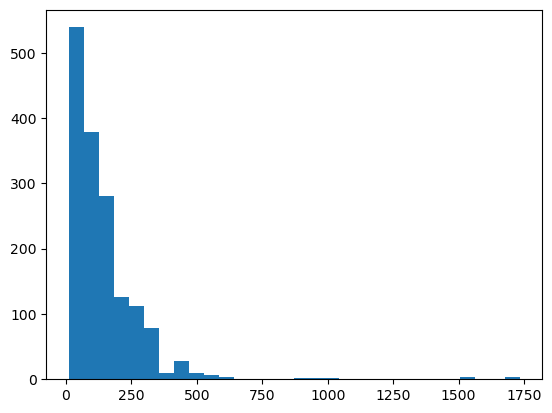

In [13]:
# filt_corr_df[['gene_name', 'n_variants']].unique()['n_variants'].describe()
plt.hist(filt_corr_df[['gene_name', 'n_variants']].unique()['n_variants'], bins=30)
plt.show()

In [14]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'gene_name', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 6
Inconsistent (region, phenotype) pairs: 970


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


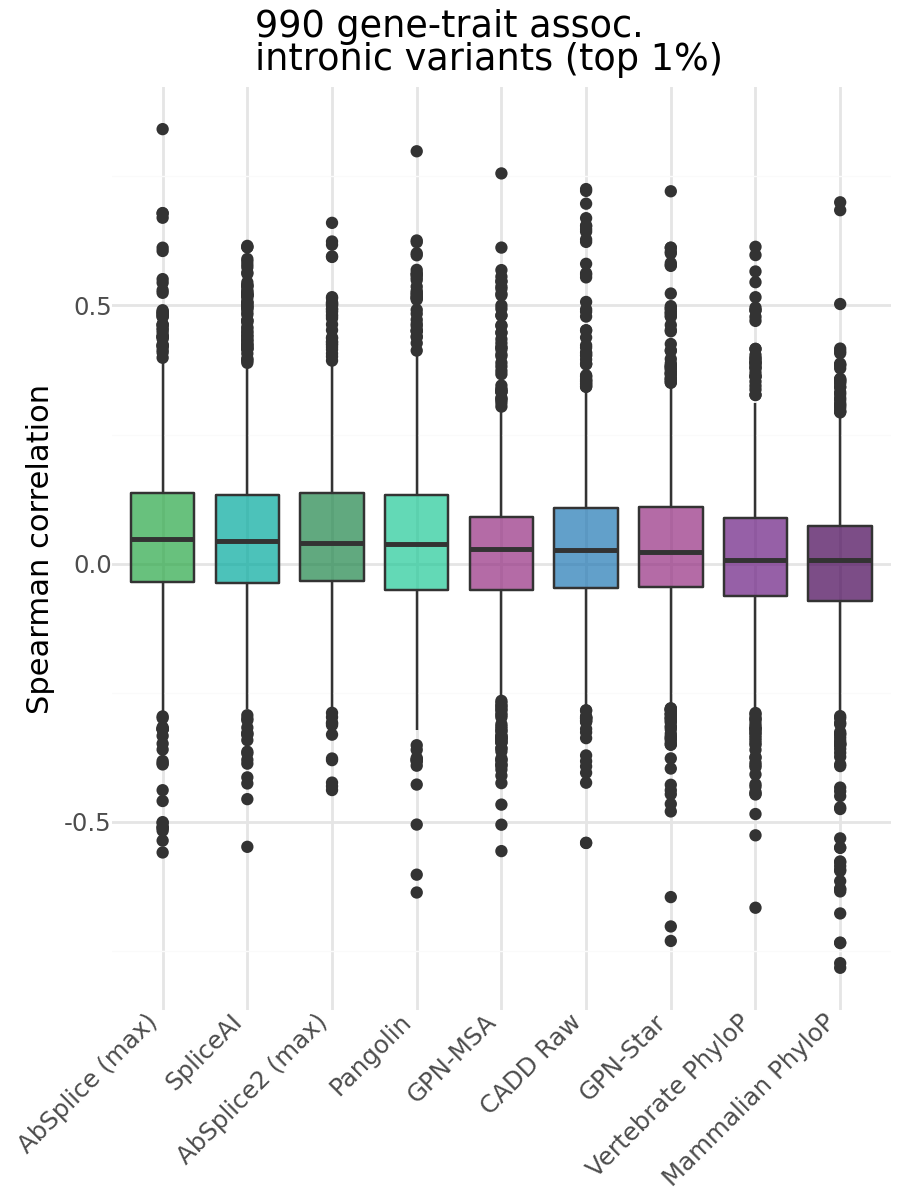

In [18]:
# Prepare for plotting
med_df = filt_corr_df.drop_nans().group_by("annotation").agg([
    pl.col("corr_beta").median().alias("median_abs_corr"),
])

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y="corr_beta", fill="annotation")) +
    geom_boxplot(alpha=0.7) +
    theme_minimal() +
    scale_fill_manual(values=color_dict) +
    # lims(
    #     y=(-0.25, 0.25)
    # ) +
    labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pd[['region', 'phenotype']].drop_duplicates().shape[0]} gene-trait assoc. \
        \n{variant_class} variants (top 1%)"
        # \n[{min_range}bp, {max_range}bp]"
    ) +
    theme(
        figure_size=(4.5, 6),
        legend_position="none",
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

In [16]:
med_df

annotation,median_abs_corr
str,f64
"""mamphylop""",0.006315
"""verphylop""",0.006806
"""cadd_raw""",0.026647
"""delta_score""",0.043279
"""gpn_score""",0.027998
"""pangolin_score""",0.03851
"""absplice2_max""",0.040085
"""absplice_dna_max""",0.047646
"""gpn_star_llr_calibrated_mean""",0.0233


In [17]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_435902/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""verphylop""","""absplice2_max""",968,177154.0,4.3786e-11
"""verphylop""","""delta_score""",967,178305.0,1.4298e-10
"""verphylop""","""absplice_dna_max""",966,184442.0,1.5193e-8
"""verphylop""","""pangolin_score""",971,187949.0,3.9817e-8
"""gpn_score""","""delta_score""",967,187478.0,8.4721e-8
…,…,…,…,…
"""gpn_star_llr_calibrated_mean""","""absplice_dna_max""",966,207557.0,0.002749
"""pangolin_score""","""gpn_score""",972,211358.0,0.004172
"""gpn_score""","""cadd_raw""",985,220994.0,0.014609
